# 15 Permutation Stratification Sensitivity

**Methods mapping:** sensitivity of the cross-branch permutation test to exchangeability strata.

This notebook compares the target cross-branch combinations under pooled, month-only, month-region, and month-region-clade permutation schemes and redraws Supplementary Fig. S8.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image as IPyImage

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('15_permutation_stratification_sensitivity', ROOT)
INPUTS = {
    'target_combo': DATA_DIR / 'permutation_stratification_target_combo.csv',
    'plot_data': DATA_DIR / 'permutation_stratification_plot_data.csv',
    'omnibus': DATA_DIR / 'permutation_stratification_omnibus.csv',
    'combo_level': DATA_DIR / 'permutation_stratification_combo_level.csv',
}
OUTPUTS = {
    'figure_png': FIG_DIR / 'Supplementary_Figure_S8_permutation_stratification_sensitivity.png',
    'figure_pdf': FIG_DIR / 'Supplementary_Figure_S8_permutation_stratification_sensitivity.pdf',
    'figure_svg': FIG_DIR / 'Supplementary_Figure_S8_permutation_stratification_sensitivity.svg',
}
display(pd.DataFrame({'input': INPUTS.keys(), 'path': [rel(p) for p in INPUTS.values()]}))
display(pd.DataFrame({'output': OUTPUTS.keys(), 'path': [rel(p) for p in OUTPUTS.values()]}))


,input,path
0,target_combo,data/processed_data/15_permutation_stratificat...
1,plot_data,data/processed_data/15_permutation_stratificat...
2,omnibus,data/processed_data/15_permutation_stratificat...
3,combo_level,data/processed_data/15_permutation_stratificat...


,output,path
0,figure_png,results/figures/15_permutation_stratification_...
1,figure_pdf,results/figures/15_permutation_stratification_...
2,figure_svg,results/figures/15_permutation_stratification_...


## Read Permutation Summaries

The target-combo table contains observed counts and null distributions for the dominant pair in each cohort across permutation schemes.


In [3]:
target_combo = pd.read_csv(INPUTS['target_combo'])
plot_data = pd.read_csv(INPUTS['plot_data'])
omnibus = pd.read_csv(INPUTS['omnibus'])
combo_level = pd.read_csv(INPUTS['combo_level'])

display(plot_data[['project_label', 'target_combo', 'analysis_mode', 'mode_label_clean', 'observed_count', 'null_mean', 'null_q025', 'null_q975', 'maxT_adjusted_p']])
display(omnibus.head())


,project_label,target_combo,analysis_mode,mode_label_clean,observed_count,null_mean,null_q025,null_q975,maxT_adjusted_p
0,Australia,C4+C6,all_unstratified,Pooled,23,10.26890,6.0,15.0,0.025899
1,Australia,C4+C6,all_month_only,Month only,23,10.67605,6.0,15.0,0.000050
2,Australia,C4+C6,all_month_region,Month-region,23,10.65840,6.0,15.0,0.000050
3,Australia,C4+C6,all_month_region_clade,Month-region-clade,23,13.05605,8.0,18.0,0.000050
4,United States,C18+C21,all_unstratified,Pooled,26,6.58425,3.0,11.0,0.000050
5,United States,C18+C21,all_month_only,Month only,26,8.08320,4.0,13.0,0.000050
6,United States,C18+C21,all_month_region,Month-region,26,9.21765,5.0,14.0,0.000050
7,United States,C18+C21,all_month_region_clade,Month-region-clade,26,15.95765,11.0,21.0,0.000050


,n_permutations,n_samples_in_null,n_haplotypes_in_null,n_permutation_groups,n_observed_cross_branch_combos,observed_max_count,observed_max_count_combos,max_count_null_mean,max_count_null_q025,max_count_null_median,max_count_null_q975,omnibus_max_count_p,observed_max_z,maxT_null_q025,maxT_null_median,maxT_null_q975,omnibus_maxT_p,top_combo,top_combo_count,top_combo_observed_expected_ratio,top_combo_maxT_adjusted_p,project,project_label,target_combo,analysis_mode,mode_label,mode_note,focal_clade,group_col,mode_order
0,20000,37,72,1,5,23,C4+C6,10.27390,6.0,10.0,15.0,0.00005,6.138635,0.224010,1.632940,6.138635,0.025899,C4+C6,23,2.239773,0.025899,PRJNA1037681,Australia,C4+C6,all_unstratified,All samples\nunstratified,"all samples, no exchangeability strata",A.D.3.1,perm_group,0
1,20000,37,72,4,5,23,C4+C6,10.67950,6.0,11.0,15.0,0.00005,5.258115,0.080726,1.505717,3.389929,0.000050,C4+C6,23,2.154355,0.000050,PRJNA1037681,Australia,C4+C6,all_month_only,All samples\nmonth only,"all samples, preserving collection month",A.D.3.1,perm_group,1
2,20000,37,72,4,5,23,C4+C6,10.66240,6.0,11.0,15.0,0.00005,5.302600,0.078428,1.506984,3.459707,0.000050,C4+C6,23,2.157922,0.000050,PRJNA1037681,Australia,C4+C6,all_month_region,All samples\nmonth+region,"all samples, preserving collection month and s...",A.D.3.1,stratum,2
3,20000,37,72,9,5,23,C4+C6,13.05605,8.0,13.0,18.0,0.00005,3.949146,-0.040851,1.382185,2.997428,0.000050,C4+C6,23,1.761635,0.000050,PRJNA1037681,Australia,C4+C6,all_month_region_clade,All samples\nmonth+region+clade,"all samples, preserving collection month, samp...",A.D.3.1,perm_group,3
4,20000,31,62,1,5,23,C4+C6,12.31325,7.0,12.0,17.0,0.00010,4.892490,-0.017458,1.401000,4.892490,0.040148,C4+C6,23,1.867907,0.040198,PRJNA1037681,Australia,C4+C6,focal_unstratified,Focal clade\nunstratified,"focal-clade samples only, no exchangeability s...",A.D.3.1,perm_group,4


## Figure

Supplementary Fig. S8 shows the target-combo observed count against the corresponding null intervals under each stratification scheme.


Saved: results/figures/15_permutation_stratification_sensitivity/Supplementary_Figure_S8_permutation_stratification_sensitivity.png, results/figures/15_permutation_stratification_sensitivity/Supplementary_Figure_S8_permutation_stratification_sensitivity.pdf, results/figures/15_permutation_stratification_sensitivity/Supplementary_Figure_S8_permutation_stratification_sensitivity.svg

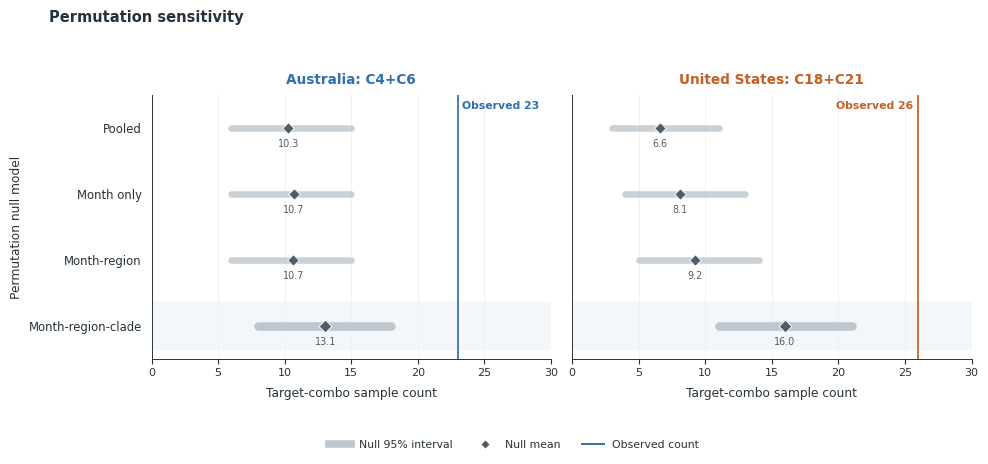

In [4]:
COLORS = {'Australia': '#2F6FAE', 'United States': '#C65F22'}
GRAY_LINE = '#BFC7CE'
GRAY_POINT = '#4F5D66'
GRID = '#EEF2F5'
TEXT = '#26323B'
PRIMARY_SHADE = '#F3F7FA'

mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 8.6,
    'axes.titlesize': 9.8,
    'axes.labelsize': 8.8,
    'xtick.labelsize': 8.0,
    'ytick.labelsize': 8.4,
    'legend.fontsize': 7.8,
    'figure.titlesize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#2B333A',
    'axes.linewidth': 0.7,
    'xtick.color': TEXT,
    'ytick.color': TEXT,
    'axes.labelcolor': TEXT,
    'text.color': TEXT,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
})

fig, axes = plt.subplots(1, 2, figsize=(9.9, 4.45), sharex=True, sharey=True)
cohorts = ['Australia', 'United States']
for ax, cohort in zip(axes, cohorts):
    sub = plot_data[plot_data['project_label'].eq(cohort)].copy().sort_values('mode_order_clean')
    ypos = list(range(len(sub)))[::-1]
    color = COLORS[cohort]
    obs = int(sub['observed_count'].iloc[0])
    ax.set_axisbelow(True)
    ax.grid(axis='x', color=GRID, linewidth=0.7)
    ax.set_xlim(0, 30)
    ax.set_xticks(range(0, 31, 5))
    ax.set_ylim(-0.5, len(sub) - 0.5)
    ax.set_title(f"{cohort}: {sub['target_combo'].iloc[0]}", color=color, fontweight='bold', pad=8)
    ax.axvline(obs, color=color, linewidth=1.4, alpha=0.88, zorder=1)
    for y, (_, row) in zip(ypos, sub.iterrows()):
        is_primary = row['analysis_mode'] == 'all_month_region_clade'
        if is_primary:
            ax.axhspan(y - 0.36, y + 0.36, color=PRIMARY_SHADE, zorder=0)
        ax.hlines(y, row['null_q025'], row['null_q975'], color=GRAY_LINE, linewidth=6.2 if is_primary else 4.7, capstyle='round', alpha=1.0 if is_primary else 0.82, zorder=2)
        ax.scatter(row['null_mean'], y, s=42 if is_primary else 34, marker='D', color=GRAY_POINT, edgecolor='white', linewidth=0.65, zorder=3)
        ax.text(row['null_mean'], y - 0.17, f"{row['null_mean']:.1f}", ha='center', va='top', fontsize=6.9, color=GRAY_POINT)
    obs_ha = 'right' if obs > 24 else 'left'
    obs_x = obs - 0.35 if obs_ha == 'right' else obs + 0.35
    ax.text(obs_x, len(sub) - 0.58, f'Observed {obs}', ha=obs_ha, va='top', color=color, fontsize=7.8, fontweight='bold')
    ax.set_xlabel('Target-combo sample count', labelpad=6)
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(plot_data[plot_data['project_label'].eq('Australia')].sort_values('mode_order_clean')['mode_label_clean'].tolist())
axes[0].tick_params(axis='y', length=0, pad=7)
axes[0].set_ylabel('Permutation null model')
axes[1].tick_params(axis='y', length=0)
legend_handles = [
    mpl.lines.Line2D([0], [0], color=GRAY_LINE, linewidth=5.5, label='Null 95% interval'),
    mpl.lines.Line2D([0], [0], marker='D', color='none', markerfacecolor=GRAY_POINT, markeredgecolor='white', markersize=5.2, label='Null mean'),
    mpl.lines.Line2D([0], [0], color='#2F6FAE', linewidth=1.4, label='Observed count'),
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.52, -0.02), ncol=3, frameon=False)
fig.suptitle('Permutation sensitivity', x=0.05, y=0.99, ha='left', fontsize=10.5, fontweight='bold')
fig.tight_layout(rect=[0, 0.09, 1, 0.93], pad=0.9)
paths = au.save_pub_figure(fig, FIG_DIR, 'Supplementary_Figure_S8_permutation_stratification_sensitivity', dpi=600)
display(Markdown('Saved: ' + ', '.join(paths.values())))
plt.show()
